In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
RANDOM_STATE = 42

# 1) Load dataset (German Credit from OpenML)
#    - 'class' is the target (good/bad). We'll use all other columns for unsupervised clustering.
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame.copy()

In [5]:
# Separate features and target
target_col = "class"
X_df = df.drop(columns=[target_col])
y = df[target_col]  # not used for clustering, but useful for optional validation later

In [18]:
# Identify numeric vs categorical features
numeric_features = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [11]:
# 3) Preprocess:
# - Standardize numeric features (important for Euclidean distance in KMeans/Ward)
# - One-hot encode categorical features (dense output for PCA)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore",min_frequency=0.02, sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_transformed = preprocess.fit_transform(X_df)

In [19]:
X_transformed

array([[-1.23647786, -0.74513141,  0.91847717, ...,  1.        ,
         0.        ,  1.        ],
       [ 2.24819436,  0.94981679, -0.87018333, ...,  0.        ,
         0.        ,  1.        ],
       [-0.73866754, -0.41656241, -0.87018333, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.73866754, -0.87450324,  0.91847717, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.9992892 , -0.50552769,  0.91847717, ...,  1.        ,
         0.        ,  1.        ],
       [ 1.9992892 ,  0.46245715,  0.02414692, ...,  0.        ,
         0.        ,  1.        ]])

In [13]:
# For later profiling, get the encoded categorical column names
oh: OneHotEncoder = preprocess.named_transformers_["cat"]
cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = oh.get_feature_names_out(categorical_features).tolist()

num_feature_names = numeric_features
transformed_feature_names = num_feature_names + cat_feature_names

In [20]:
assert X_transformed.shape[1] == len(transformed_feature_names)

In [22]:
# 4) Elbow method (KMeans inertias over k=1..10)
k_values = list(range(1, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_transformed)
    inertias.append(km.inertia_)

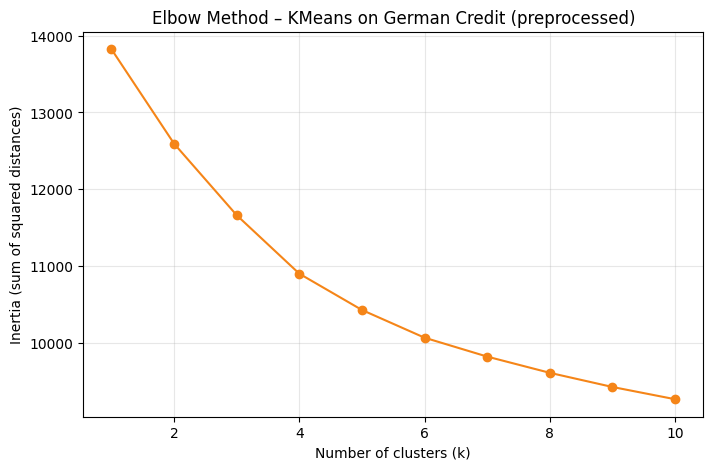

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='#F58518')
plt.title("Elbow Method – KMeans on German Credit (preprocessed)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
k_opt = 3

In [54]:
# 5) PCA (2D) for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_transformed)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

Explained variance ratio (PC1, PC2): [0.132 0.116]


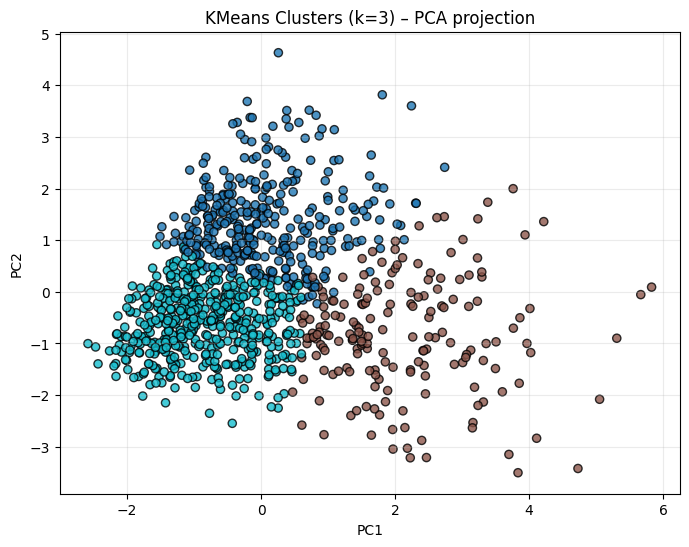

In [55]:
# 6) Fit KMeans with k_opt and visualize
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_transformed)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"KMeans Clusters (k={k_opt}) – PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

In [56]:
#3D
pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_transformed)
print("Explained variance ratio (PC1, PC2, PC3):", np.round(pca.explained_variance_ratio_, 3))


km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_transformed)

df_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "cluster": km_labels.astype(str)
})

fig = px.scatter_3d(
    df_plot, x="PC1", y="PC2", z="PC3",
    color="cluster",
    opacity=0.8,
    title=f"KMeans Clusters (k={k_opt}) – PCA 3D projection"
)
fig.show()

Explained variance ratio (PC1, PC2, PC3): [0.132 0.116 0.084]


In [57]:
sil_km = silhouette_score(X_transformed, km_labels)
print(f"\nSilhouette score (KMeans, k={k_opt}): {sil_km:.3f}")


Silhouette score (KMeans, k=3): 0.093


In [45]:
#Group similar features together PCA approach
X_df_pca = X_df.copy()

X_num = X_df_pca.loc[:,numeric_features]

X_scaled = StandardScaler().fit_transform(X_num)

X_feat = X_scaled.T

pca_feat = PCA(n_components=2, random_state=42)
X_feat_pca = pca_feat.fit_transform(X_feat)


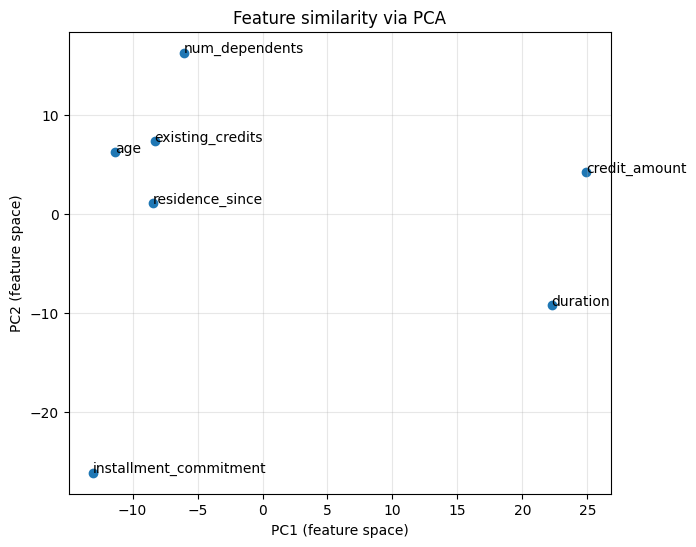

In [46]:
plt.figure(figsize=(7, 6))
plt.scatter(X_feat_pca[:, 0], X_feat_pca[:, 1])

for i, name in enumerate(numeric_features):
    plt.text(X_feat_pca[i, 0], X_feat_pca[i, 1], name)

plt.xlabel("PC1 (feature space)")
plt.ylabel("PC2 (feature space)")
plt.title("Feature similarity via PCA")
plt.grid(True, alpha=0.3)
plt.show()


/tmp/ipython-input-2678338078.py:6: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



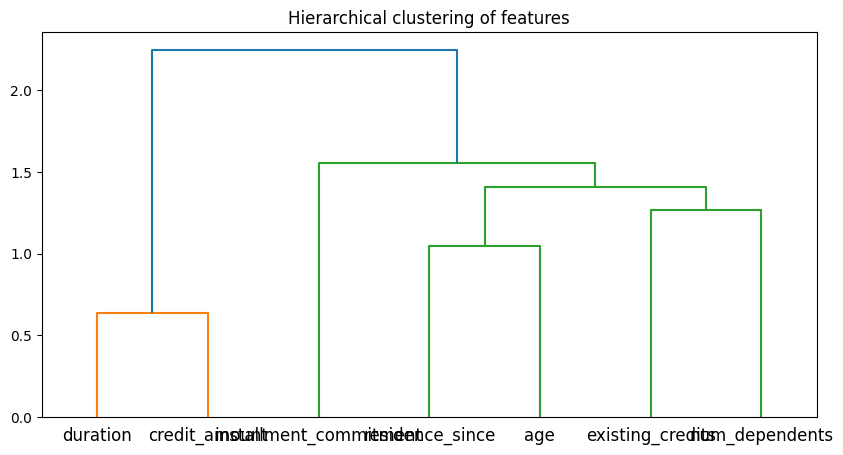

In [47]:
#Group similar features together hierarchical approach

from scipy.cluster.hierarchy import linkage, dendrogram

corr = np.corrcoef(X_scaled, rowvar=False)
Z = linkage(1 - corr, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=numeric_features)
plt.title("Hierarchical clustering of features")
plt.show()
